# PSI Numerical Methods - solving ODEs

In [3]:
import numpy as np
import matplotlib.pylab as plt

In [61]:
'''
Our top-level function for evolving an ODE starting from an initial condition.
We have to give it the derivative function ("f"), and the step function ("step"),
Along with a description of the time steps and the initial conditions ("x0").
'''
def evolve(t0, t1, x0, N, f, f_kwargs, step):
    # create the time grid
    t = np.linspace(t0, t1, N+1)
    # pre-allocate space for the x values at each step
    Ndim = len(x0)
    x = np.zeros((N+1, Ndim))
    # initialize the state
    x[0,:] = x0
    for i in range(N):
        # time step size (constant in this function)
        h = t[i+1] - t[i]
        # use the step function to step forward!
        x[i+1, :] = step(t[i], x[i,:], h, f, f_kwargs)
    return t, x

In [62]:
'''
The Classic: Forward Euler stepping function.  Extrapolates the derivative at the current point.
'''
def step_forward_euler(t, x, h, f, f_kwargs):
    x_next = x + h * f(t, x, **f_kwargs)
    return x_next

In [86]:
def step_midpoint(t, x, h, f, f_kwargs):
    x_half = x + h/2. * f(t, x, **f_kwargs)
    t_half = t + h/2.
    x_next = x + h * f(t_half, x_half, **f_kwargs)
    return x_next

In [63]:
'''
The Workhorse: Runge-Kutta 4
'''
def step_rk4(t, x, h, f, f_kwargs):
    # RK4 evaluates the derivative at 4 points; we'll call these k_1 through k_4.

    # k1: the Forward Euler slope
    k1 = f(t, x, **f_kwargs)
    # Step half-way
    t1 = t + h/2.
    x1 = x + h/2. * k1

    # k2: like the RK2 / midpoint rule: evaluate the slope half-way through the time interval.
    k2 = f(t1, x1, **f_kwargs)
    # Step half-way, but using the slope from k2
    t2 = t + h/2.
    x2 = x + h/2. * k2

    k3 = f(t2, x2, **f_kwargs)
    t3 = t + h
    x3 = x + h * k3

    # k4 evaluates the slope and the end-point of the time interval
    k4 = f(t3, x3, **f_kwargs)

    # RK4 combines those 4 estimates of k with this magic:
    x_next = x + h/6. * (k1 + 2.*k2 + 2.*k3 + k4)
    return x_next

In [64]:
'''
Simple Harmonic Oscillator (no damping):

F = -k r = m r''

r'' = -k/m r

Define
omega**2 = k/m

We use Reduction of Order to turn this into a 2-d first-order ODE.

The vector x is assumed to be length-2, where x[0] is the position ("r" in the equation above)
and x[1] is the velocity.
'''
def f_harmonic_osc(t, x, omega=1.0):
    xdot = np.zeros(2)
    # derivative of the position is just the velocity
    xdot[0] = x[1]
    # derivative of the velocity 
    xdot[1] = -omega**2 * x[0]
    return xdot

In [65]:
'''
Newtonian gravity, with a fixed large mass at the origin; the one-body problem.

The vector x is assumed to be length 6:
  x[0],x[1],x[2] is the position in Cartesian coordinates
  x[4],x[5],x[6] is the velocity in Cartesian coordinates

'''
def f_newton_onebody(t, x, GM=1.):
    # pull out the position and velocity vectors
    r = x[:3]
    v = x[3:]
    # compute the radius from the massive gravitating body (eg the Sun)
    R = np.sqrt((r**2).sum())
    # compute the acceleration term.
    # (note tha "GM" and "R" are scalars; r is a vector, so the result is a vector.
    g = -GM / R**2 * r / R
    # could also write this, eg,
    # g = -r * (GM / R**3)
    xdot = np.zeros(6)
    xdot[:3] = v
    xdot[3:] = g
    return xdot

In [90]:
# Let's set up and solve the Simple Harmonic Oscillator
t0, t1 = (0., 20.)
N = 100
x0 = np.array([1.0, 0.0])
f_kwargs = {}
#f_kwargs = { 'omega': 4. }
#f_kwargs = dict(omega=4.)
t, x = evolve(t0, t1, x0, N, f_harmonic_osc, f_kwargs, step_forward_euler)

In [91]:
N2 = 200
t2, x2 = evolve(t0, t1, x0, N2, f_harmonic_osc, f_kwargs, step_forward_euler)

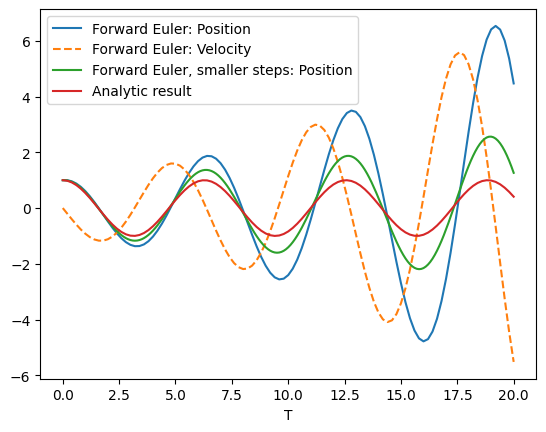

In [92]:
plt.plot(t, x[:, 0], '-', label='Forward Euler: Position')
plt.plot(t, x[:, 1], '--', label='Forward Euler: Velocity')
plt.plot(t2, x2[:, 0], '-', label='Forward Euler, smaller steps: Position')
plt.plot(t, np.cos(t * f_kwargs.get('omega', 1.)), '-', label='Analytic result')
plt.legend()
plt.xlabel('T');

In [106]:
# Let's look at the error at the endpoint after running up to 6 cycles.  We know the answer should be 1.
t0, t1 = (0., 6. * np.pi)
x0 = np.array([1.0, 0.0])

# The number of steps to take.
NN = np.logspace(base=10, start=2, stop=5, num=10).astype(int)
# The errors for each method
errors_fe = np.zeros(len(NN))
errors_mp = np.zeros(len(NN))
errors_rk4 = np.zeros(len(NN))

for i,N in enumerate(NN):
    t, x = evolve(t0, t1, x0, N, f_harmonic_osc, f_kwargs, step_forward_euler)
    # x[-1, 0] is the last time step, position.
    errors_fe[i] = np.abs(x[-1, 0] - 1)
    t, x = evolve(t0, t1, x0, N, f_harmonic_osc, f_kwargs, step_rk4)
    errors_rk4[i] = np.abs(x[-1, 0] - 1)
    t, x = evolve(t0, t1, x0, N, f_harmonic_osc, f_kwargs, step_midpoint)
    errors_mp[i] = np.abs(x[-1, 0] - 1)

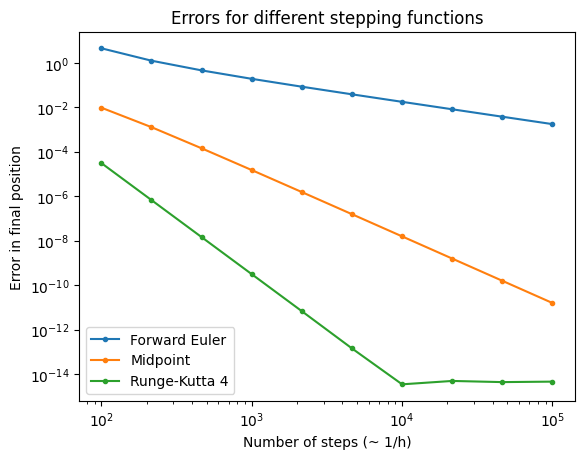

In [108]:
plt.loglog(NN, errors_fe, '.-', label='Forward Euler')
plt.loglog(NN, errors_mp, '.-', label='Midpoint')
plt.loglog(NN, errors_rk4, '.-', label='Runge-Kutta 4')
plt.legend()
plt.title('Errors for different stepping functions')
plt.xlabel('Number of steps (~ 1/h)')
plt.ylabel('Error in final position');

In [117]:
# Let's set up and solve the Newtonian gravity problem
t0, t1 = (0., 40.)
N = 800
# Set the initial position and velocity.
x0 = np.array([1.0, 0.0, 0.0,
              0.0, 0.8, 0.0])
f_kwargs = {}
# You can change the mass of the Sun like this,
# f_kwargs = dict(GM=2.)

t, x = evolve(t0, t1, x0, N, f_newton_onebody, f_kwargs, step_forward_euler)
t2, x2 = evolve(t0, t1, x0, N, f_newton_onebody, f_kwargs, step_rk4)

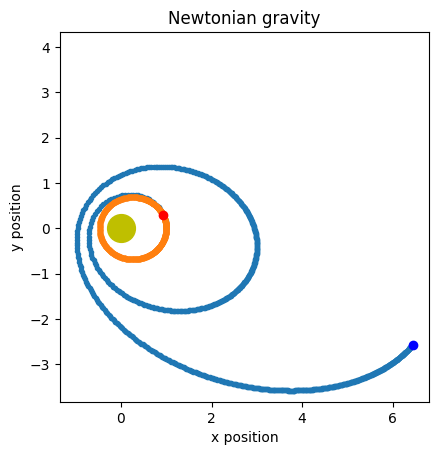

In [119]:
# big yellow Sun
plt.plot([0], [0], 'yo', ms=20);

plt.plot(x[:, 0], x[:, 1], '.-', label='Forward Euler')
plt.plot(x[-1,0], x[-1,1], 'bo')

plt.plot(x2[:, 0], x2[:, 1], '.-', label='RK4')
plt.plot(x2[-1,0], x2[-1,1], 'ro')

plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Newtonian gravity')

plt.axis('square');